## libs import

In [9]:
import sqlite3
import pandas as pd

## connection

In [10]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

## query for date from checker for users

In [11]:
query = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%';
"""
df = pd.read_sql_query(query, connection)
df['date'] = pd.to_datetime(df['timestamp']).dt.date
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
df.drop('timestamp', axis=True, inplace=True)

## df preprocessing

In [12]:
df_commits_counts = pd.DataFrame(df.value_counts()).reset_index()

In [13]:
df_commits_counts['weekday'] = pd.to_datetime(df_commits_counts['date'], format = "%Y:%m:%d").dt.weekday
df_commits_counts['is_workday'] = (df_commits_counts.weekday<5)*1

In [14]:
df_commits_counts.head()

,date,hour,count,weekday,is_workday
0,2020-05-14,21,109,3,1
1,2020-05-14,16,105,3,1
2,2020-05-02,11,84,5,0
3,2020-05-13,21,74,2,1
4,2020-05-14,15,73,3,1


In [15]:
df_grouping = df_commits_counts[df_commits_counts['count'] > 0][['hour', 'count', 'is_workday']].groupby(['hour', 'is_workday']).mean().reset_index()

In [16]:
df_grouping.head()

,hour,is_workday,count
0,0,0,2.0
1,0,1,3.0
2,1,0,6.0
3,3,0,1.0
4,3,1,2.0


## pivot table creating: counts of commits per hour at working day or weekend

In [17]:
df_pivot = df_grouping.pivot(index='hour', columns='is_workday', values='count')

In [18]:
df_pivot.columns = ["weekend", "working_day"]
df_pivot.head()

,weekend,working_day
hour,,
0,2.0,3.0
1,6.0,NaN
3,1.0,2.0
5,2.0,7.5
6,NaN,1.5


In [19]:
all_hours = pd.DataFrame(index=list(range(0,24)), columns=df_pivot.columns).combine_first(df_pivot)

In [20]:
all_hours.head()

,weekend,working_day
0,2.0,3.0
1,6.0,NaN
2,NaN,NaN
3,1.0,2.0
4,NaN,NaN


## Plot. Commits per hour

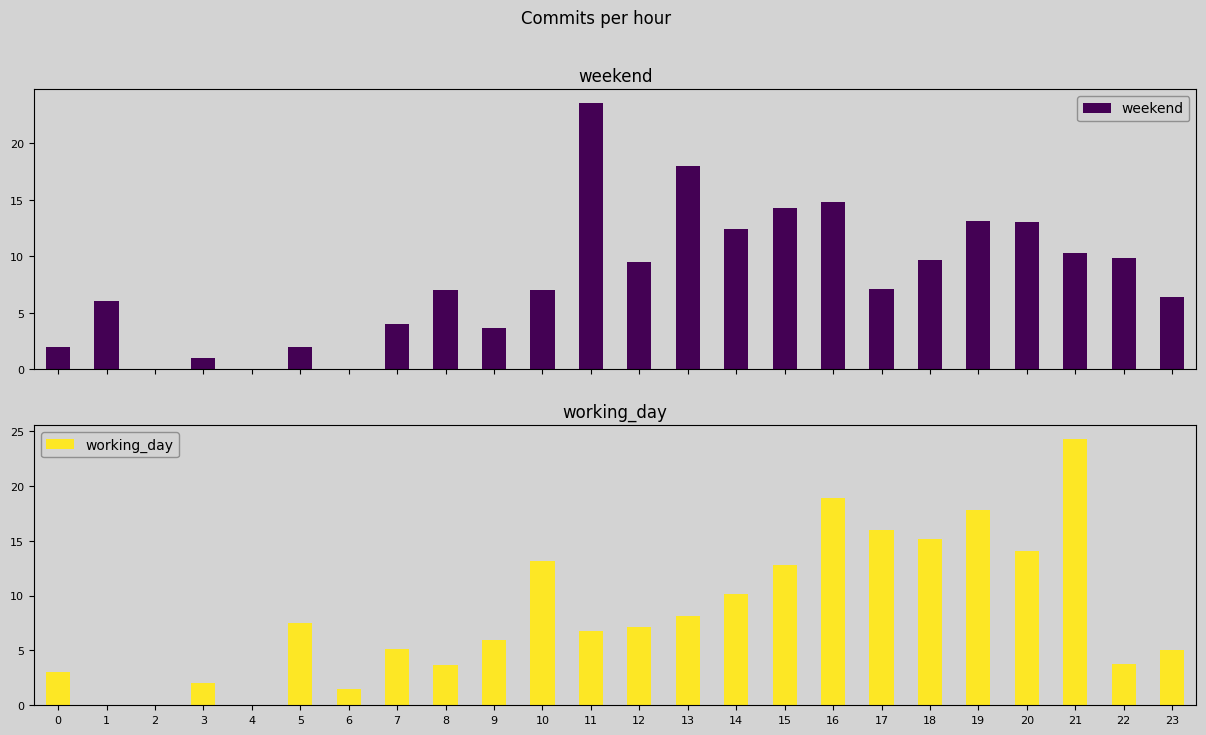

In [29]:
axes = all_hours.plot(kind = 'bar', subplots=True, layout=(2, 1), colormap='viridis',
              figsize=(15, 8), fontsize=8, title="Commits per hour")
axes[0, 0].figure.set_facecolor('lightgray')
for ax in axes.flatten():
    ax.set_facecolor('lightgray')
    ax.tick_params(axis='x', rotation=0)
    legend = ax.get_legend()
    if legend:  # Проверяем, есть ли легенда
        legend.get_frame().set_facecolor('lightgray')  # Заливаем фон легенды серым
        legend.get_frame().set_edgecolor('gray')  # Устанавливаем цвет рамки легенды (опционально)

## Answer for question:

### “Is the dynamic different on working days and weekends?”, 
### The hour when the number of commits is the largest during working days - 21;
### The hour when it is the largest during the weekend - 11;

## connection close

In [30]:
connection.close()